### **Załadowanie bibliotek**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Wczytanie danych**


In [ ]:
dane = pd.read_csv("dane_korelacja.csv")

In [ ]:
dane.head()

,Ocena,Initial Loan Amount,Loan Rate Percent,Term,Currency,Country,Loan Originator,Loan Type,Loan Status,Buyback reason,Mintos Risk Score,Collateral,Initial LTV,Extendable schedule
0,problematyczna,300000.0,22.0,48,KZT,Kazakhstan,IDF Eurasia,Personal Loan,Finished prematurely,Buyback,6.6,No,0,Yes
1,problematyczna,345000.0,22.0,48,KZT,Kazakhstan,IDF Eurasia,Personal Loan,Finished prematurely,Buyback,6.6,No,0,Yes
2,problematyczna,250000.0,22.0,36,KZT,Kazakhstan,IDF Eurasia,Personal Loan,Finished prematurely,Buyback,6.6,No,0,Yes
3,problematyczna,322000.0,22.0,48,KZT,Kazakhstan,IDF Eurasia,Personal Loan,Finished prematurely,Buyback,6.6,No,0,Yes
4,problematyczna,275000.0,22.0,36,KZT,Kazakhstan,IDF Eurasia,Personal Loan,Finished prematurely,Buyback,6.6,No,0,Yes


### **Korelacja zmiennych ilościowych**

In [ ]:
zmienne_ilosciowe = dane.select_dtypes(include = [np.number])

In [ ]:
corr = zmienne_ilosciowe.corr()

In [ ]:
corr_df = corr.stack().reset_index()
corr_df.columns = ['Var1', 'Var2', 'Correlation']

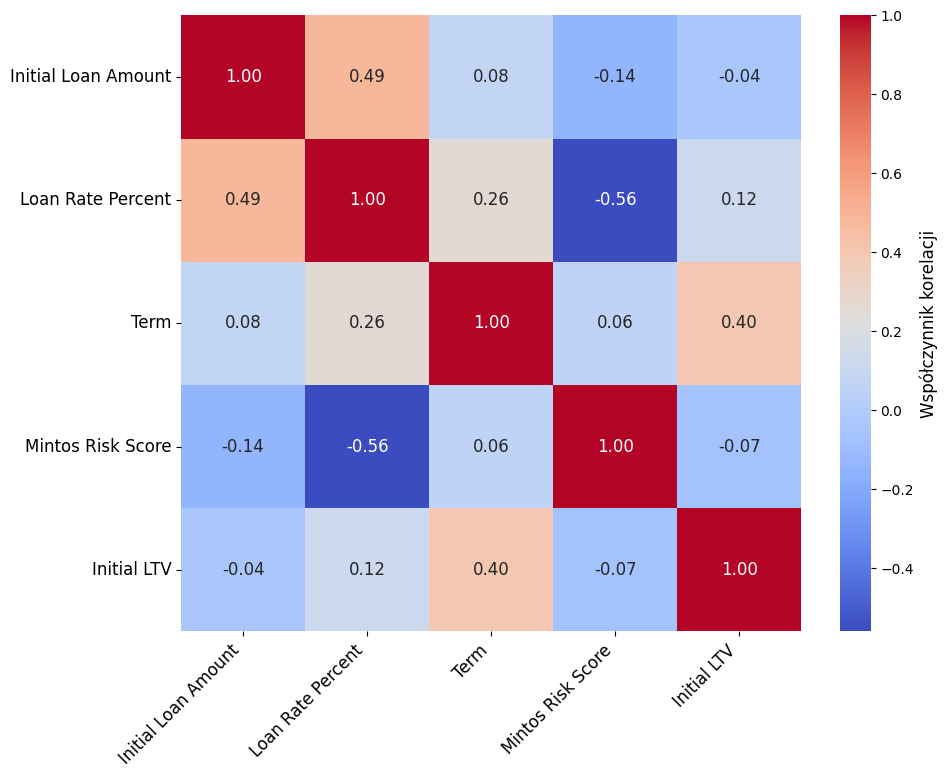

In [ ]:
plt.figure(figsize = (10,8))
cmap = "coolwarm"
heatmap = sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, cbar_kws={'label': 'Współczynnik korelacji'}, annot_kws={"size":12})
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment = 'right', fontsize = 12)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize = 12)

cbar = heatmap.collections[0].colorbar
cbar.set_label("Współczynnik korelacji", fontsize = 12)

plt.show()

### **Rozkłady zmiennych ilościowych i jakościowych**



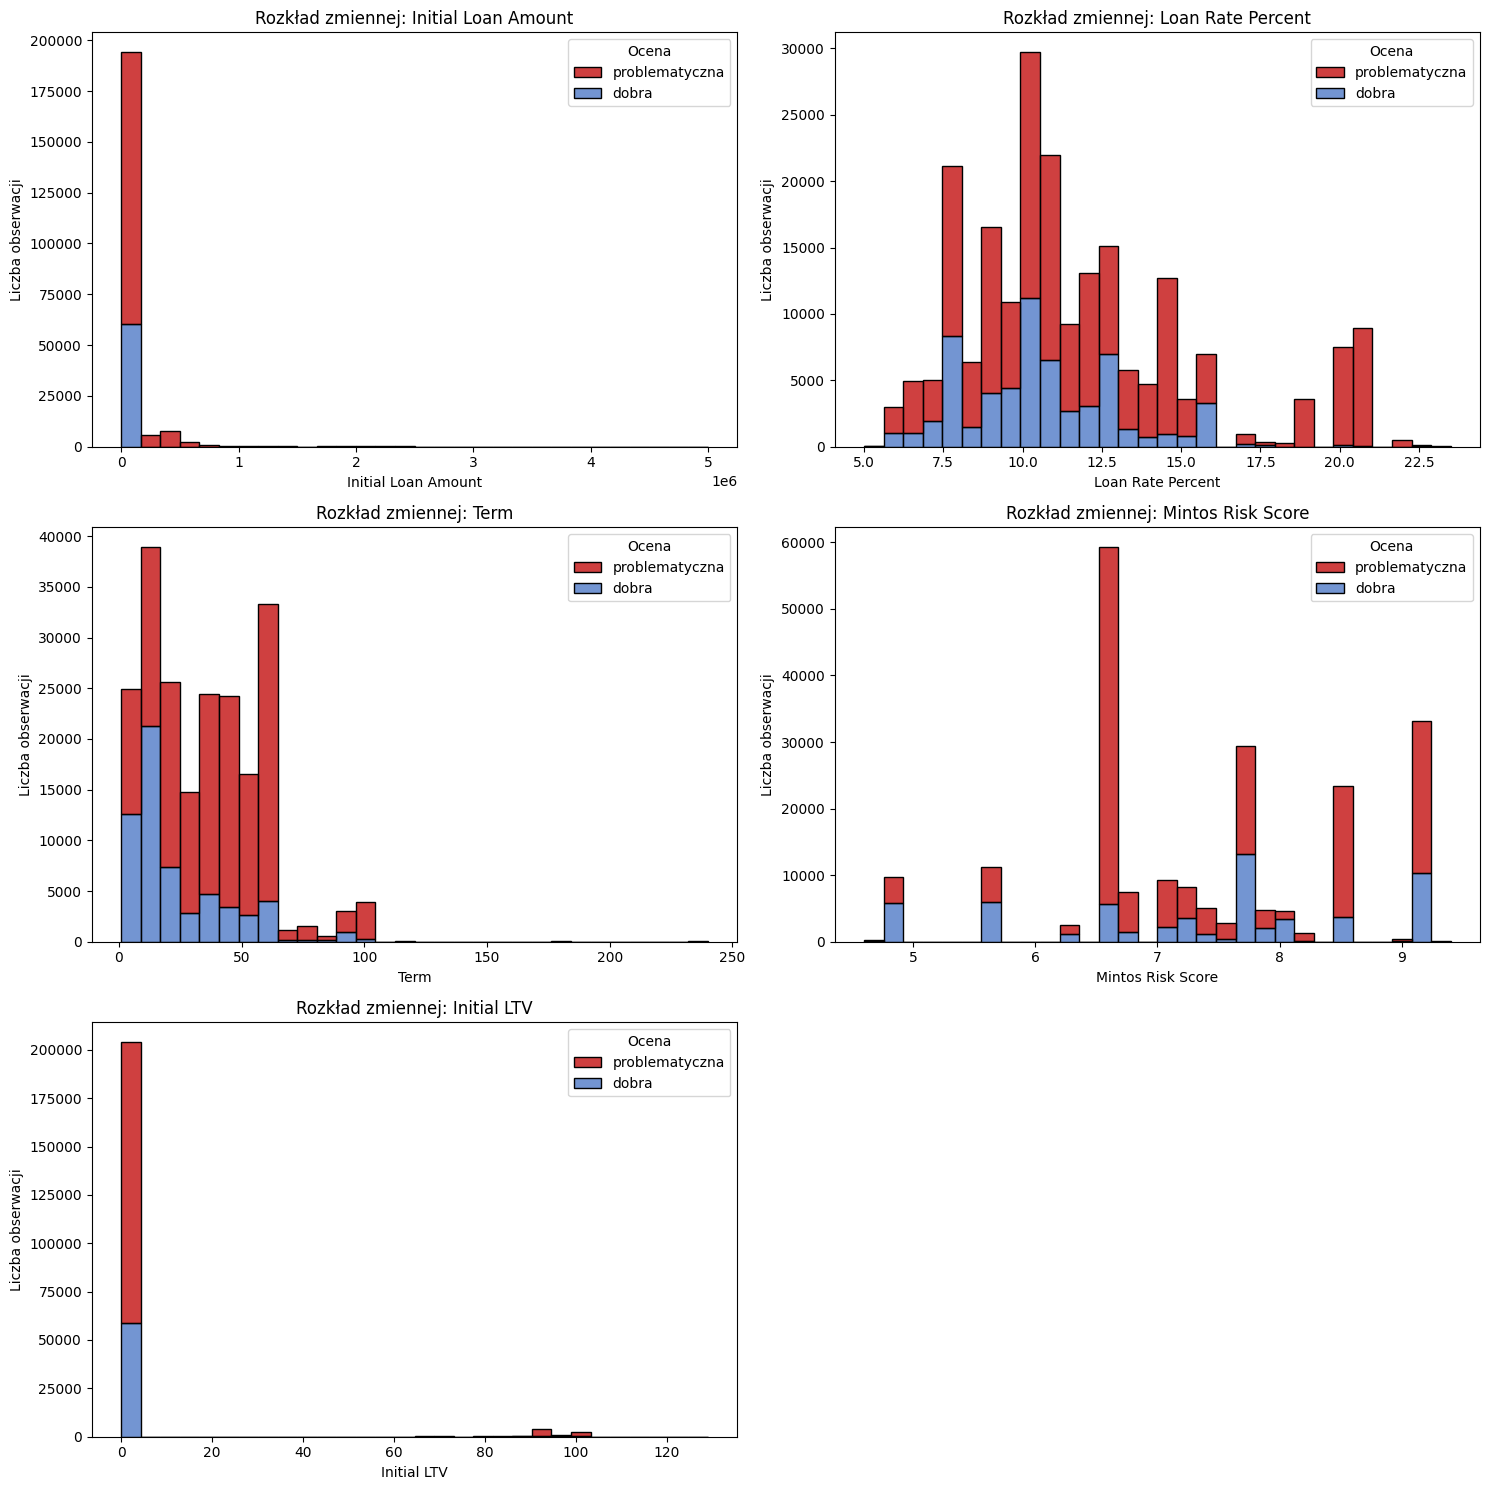

In [ ]:
num_cols = 2
num_rows = (len(zmienne_ilosciowe.columns) + num_cols - 1) // num_cols

fig, axs = plt.subplots(num_rows,num_cols,figsize=(15, 5 * num_rows))
axs = np.array(axs).reshape(-1)

# Utworzenie histogramu dla każdej zmiennej ilościowej
for i, column in enumerate(zmienne_ilosciowe.columns):
    sns.histplot(data=dane,x=column,hue='Ocena',bins=30,ax=axs[i],multiple='stack',
    palette= {'dobra': '#4472C4','problematyczna': '#C00000'})
    axs[i].set_title(f'Rozkład zmiennej: {column}')
    axs[i].set_ylabel('Liczba obserwacji')

for i in range(len(zmienne_ilosciowe.columns), len(axs)):
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
zmienne_jakosciowe = dane.select_dtypes(include=['object']).drop(columns=['Ocena'])

In [ ]:
dane['Buyback reason'] = dane['Buyback reason'].replace('-', 'No buyback')

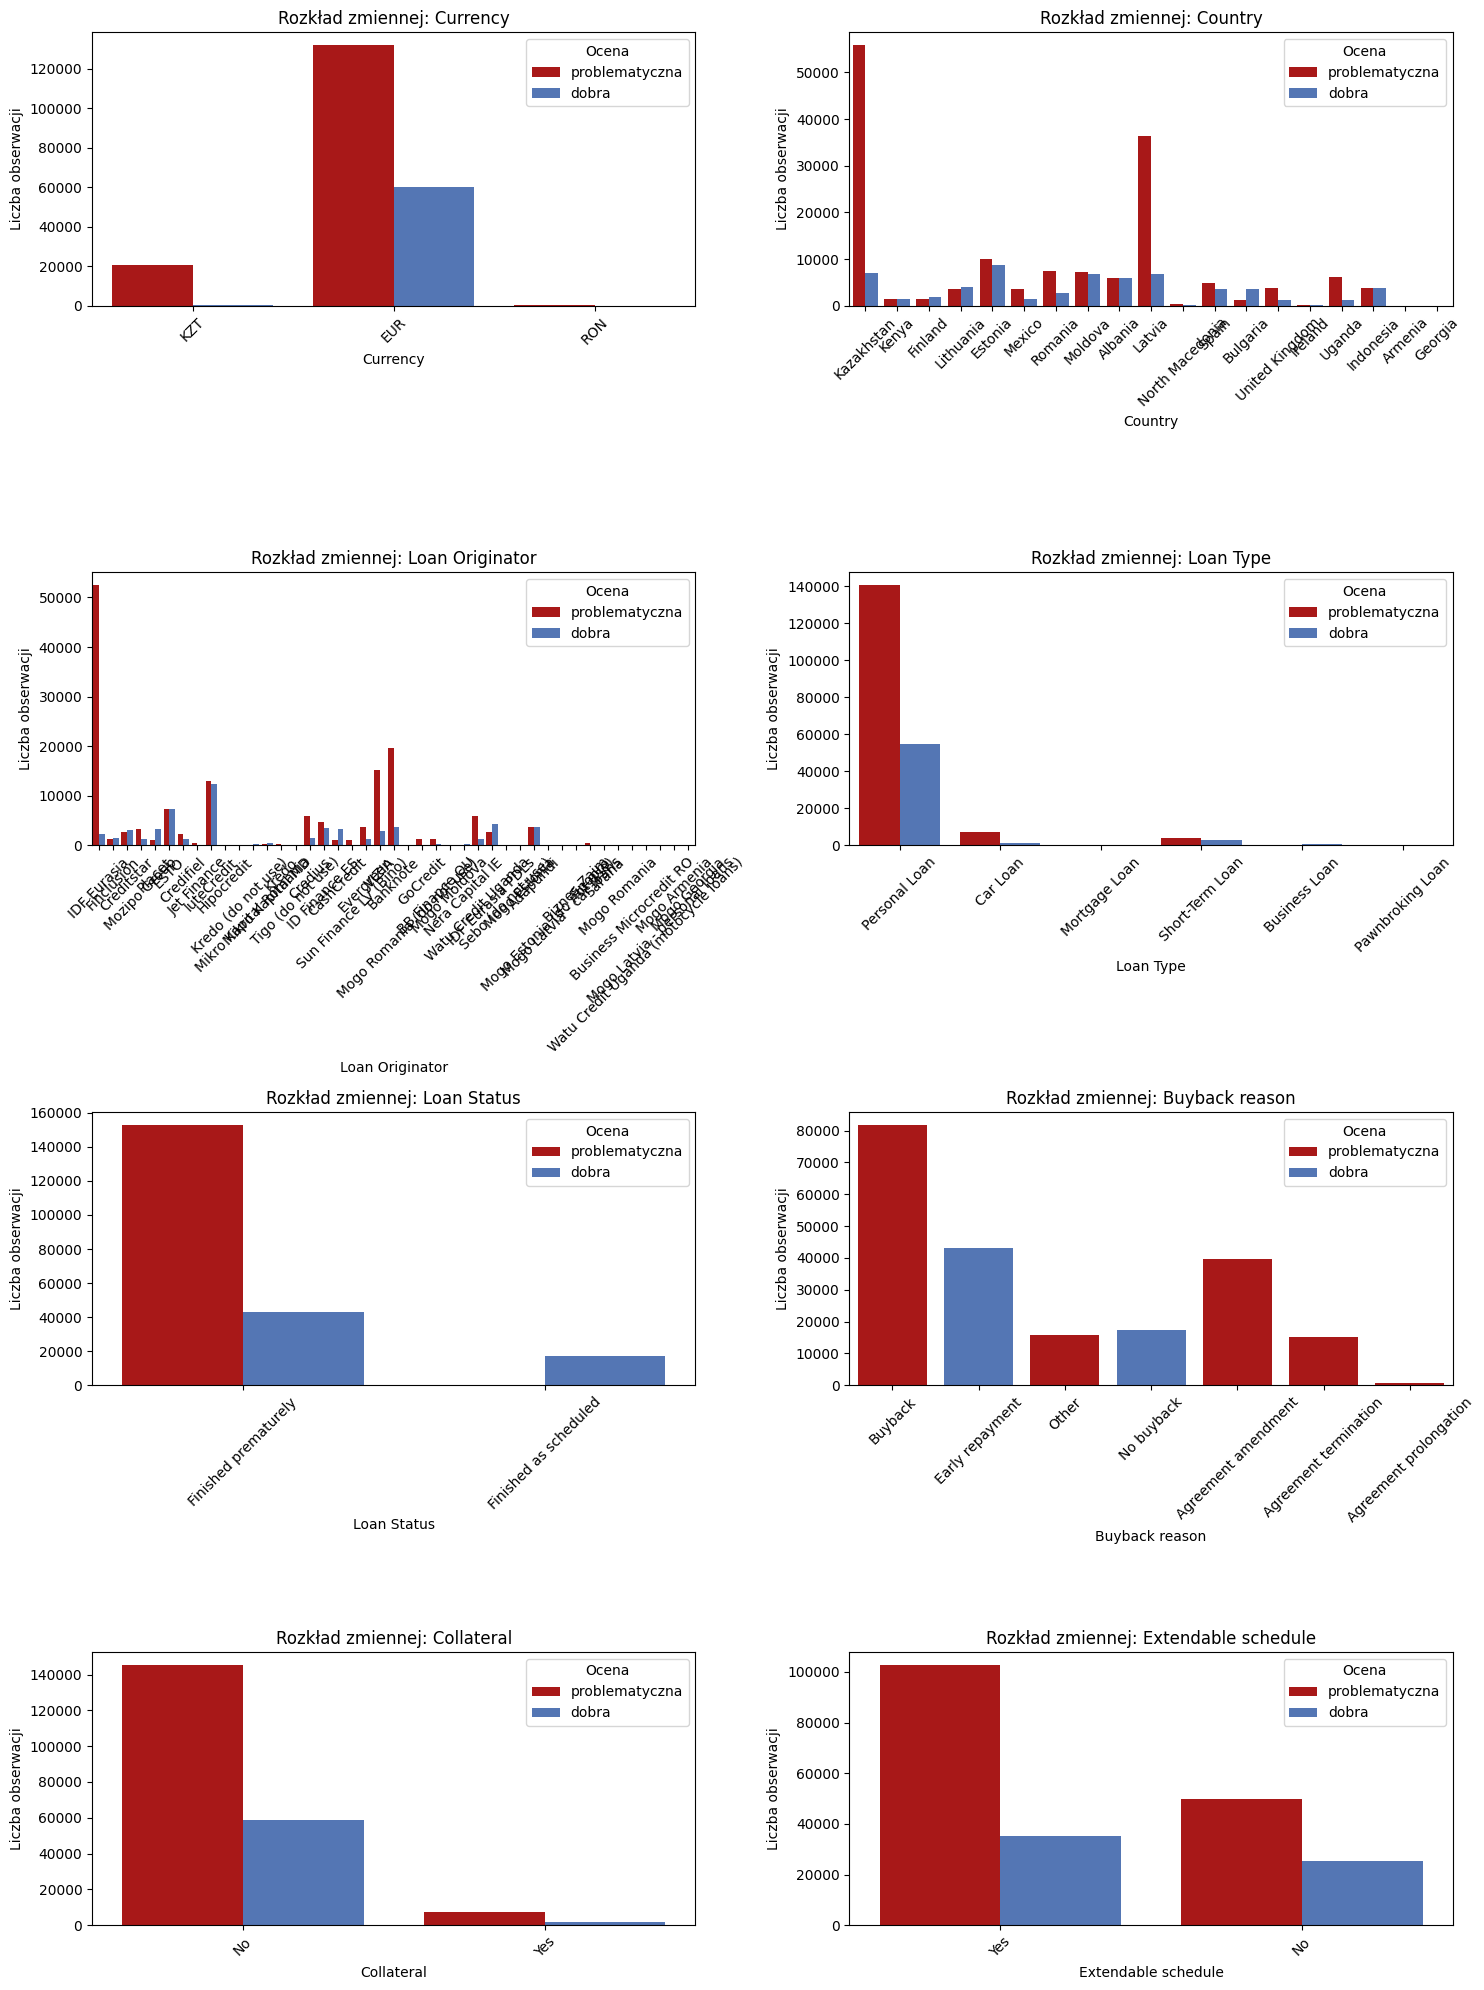

In [ ]:
num_cols = 2
num_rows = (len(zmienne_jakosciowe.columns) + num_cols - 1) // num_cols

fig, axs = plt.subplots(num_rows,num_cols,figsize=(15, 5 * num_rows))
axs = np.array(axs).reshape(-1)

for i, column in enumerate(zmienne_jakosciowe.columns):
    sns.countplot(
        data=dane,
        x=column,
        hue='Ocena',
        ax=axs[i],
        palette={
            'dobra': '#4472C4',
            'problematyczna': '#C00000'})

    axs[i].set_title(f'Rozkład zmiennej: {column}')
    axs[i].set_ylabel('Liczba obserwacji')
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Dla zmiennych Country i Loan Originator nazwy kategorii nachodzą na siebie, więc poszerzono wykresy.

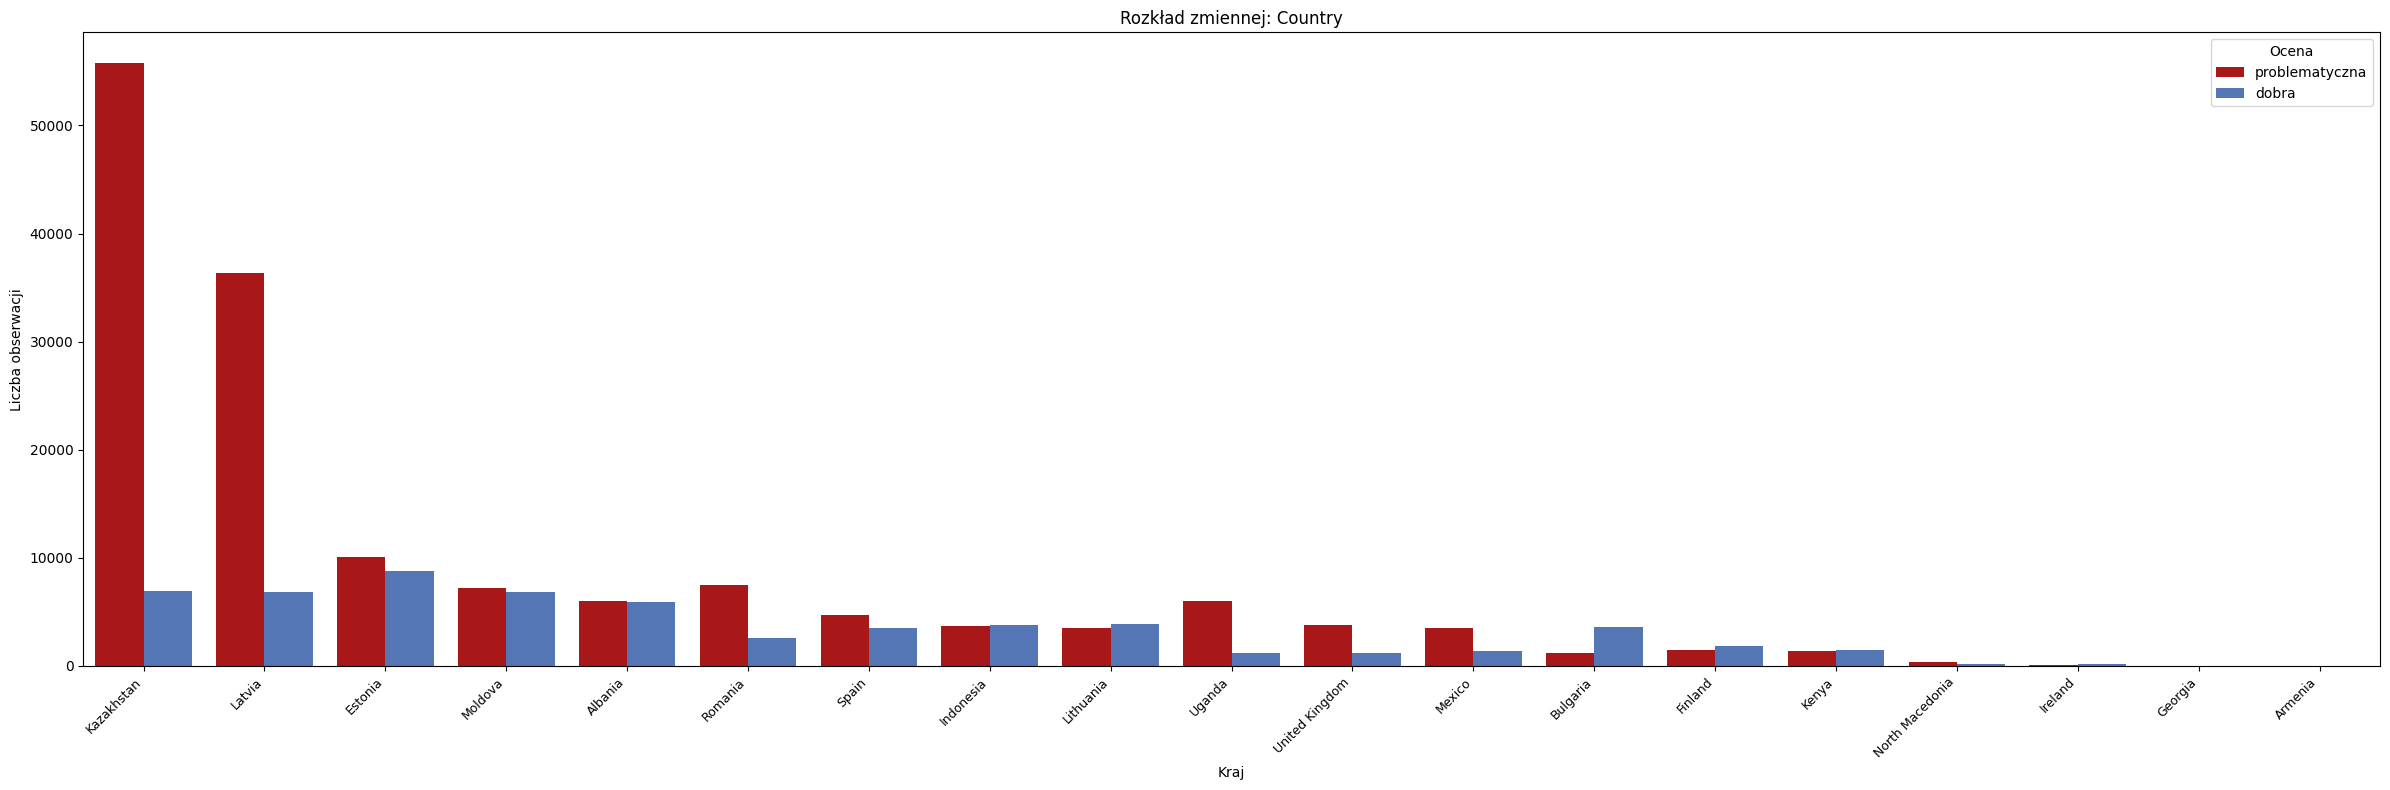

In [ ]:
plt.figure(figsize=(24, 8))

sns.countplot(
    data=dane,
    x='Country',
    hue='Ocena',
    order=dane['Country'].value_counts().index,
    palette={'dobra': '#4472C4','problematyczna': '#C00000'})

plt.title('Rozkład zmiennej: Country')
plt.ylabel('Liczba obserwacji')
plt.xlabel('Kraj')
plt.xticks(rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

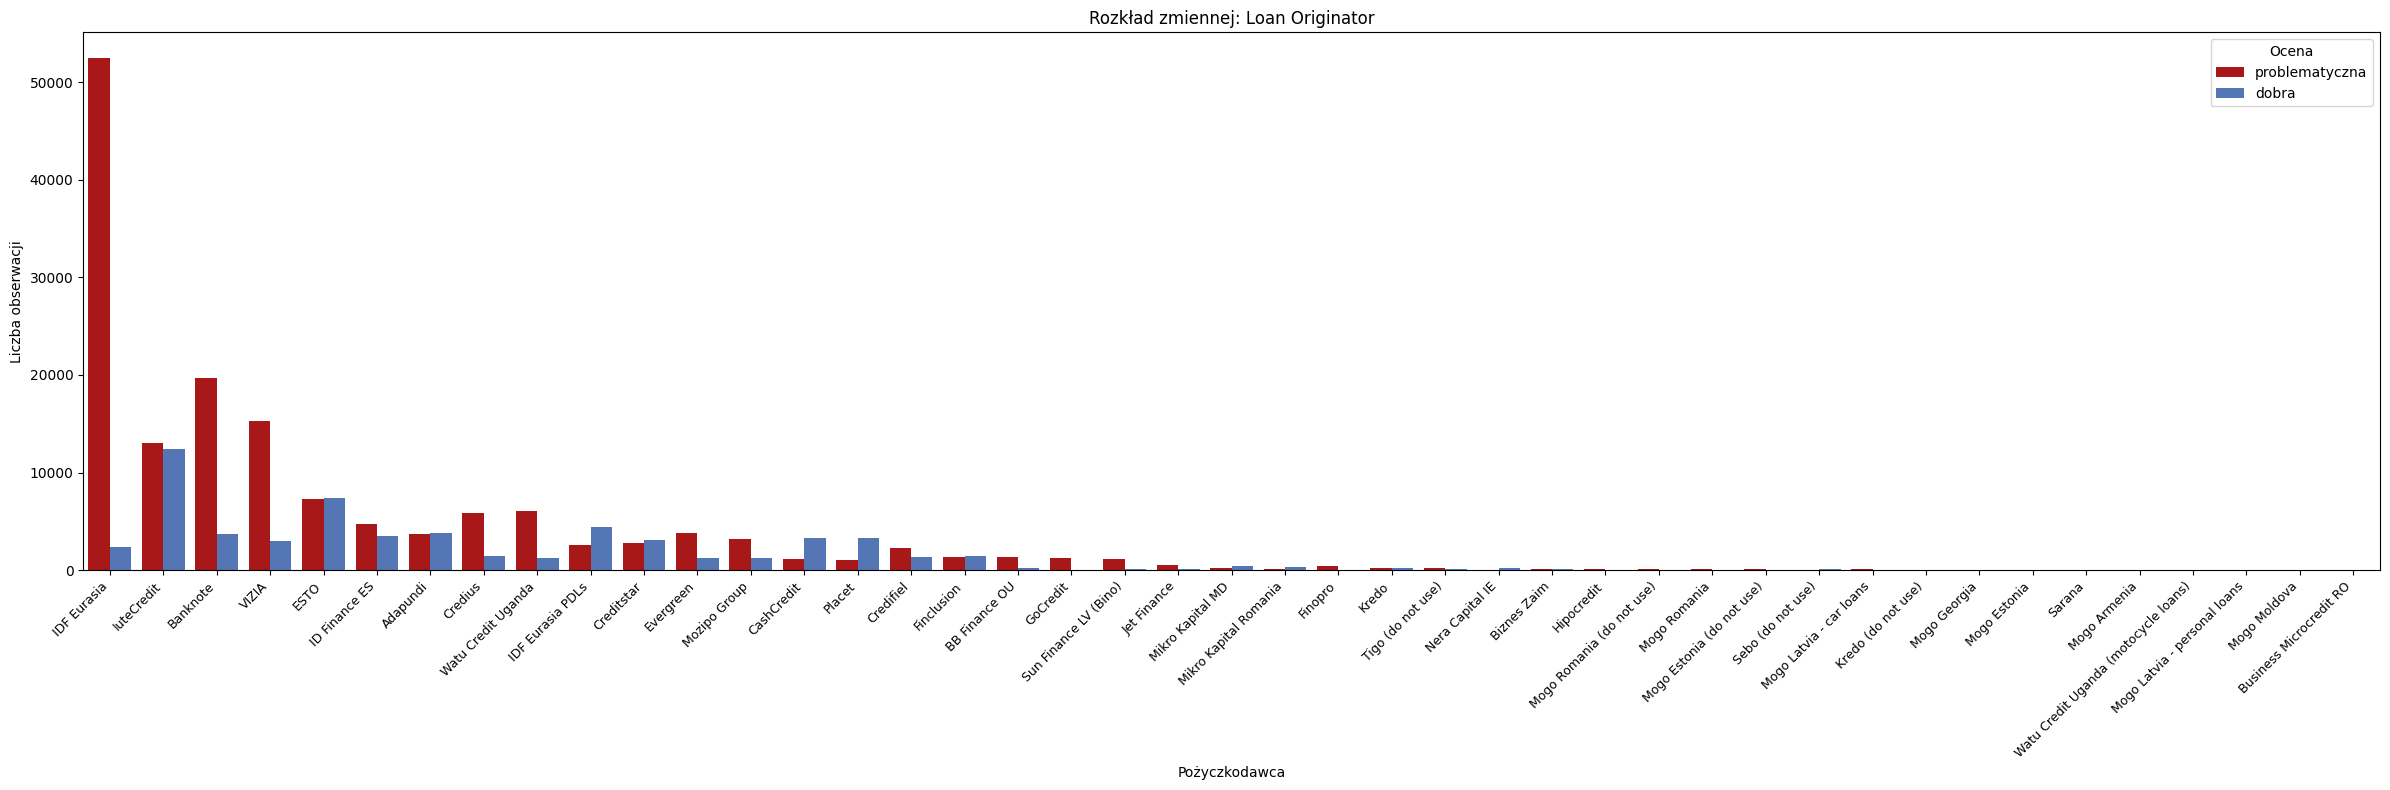

In [ ]:

plt.figure(figsize=(24, 8))

sns.countplot(
    data=dane,
    x='Loan Originator',
    hue='Ocena',
    order=dane['Loan Originator'].value_counts().index,
    palette={'dobra': '#4472C4','problematyczna': '#C00000'})

plt.title('Rozkład zmiennej: Loan Originator')
plt.ylabel('Liczba obserwacji')
plt.xlabel('Pożyczkodawca')
plt.xticks(rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

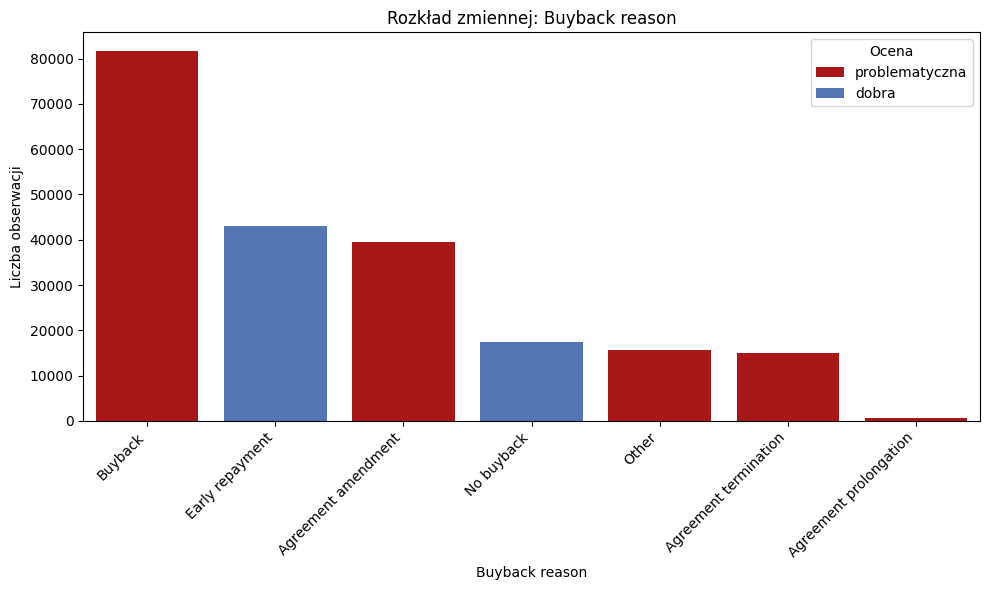

In [ ]:
kolejnosc_buyback = (dane['Buyback reason'].value_counts().index)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=dane,
    x='Buyback reason',
    hue='Ocena',
    order=kolejnosc_buyback,
    palette={'dobra': '#4472C4','problematyczna': '#C00000'})

plt.title('Rozkład zmiennej: Buyback reason')
plt.xlabel('Buyback reason')
plt.ylabel('Liczba obserwacji')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

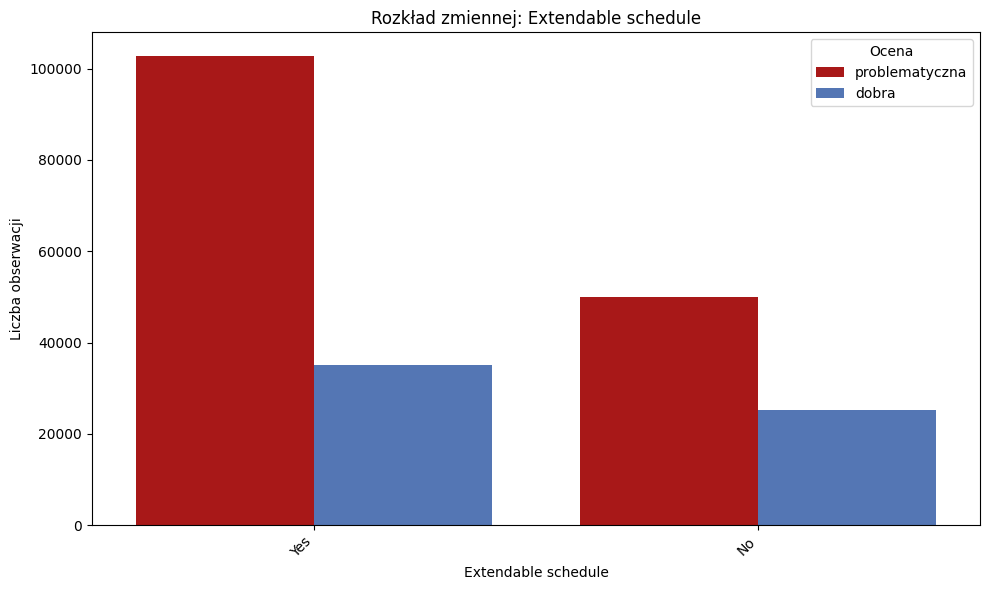

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=dane,
    x='Extendable schedule',
    hue='Ocena',
    palette={'dobra': '#4472C4','problematyczna': '#C00000'})

plt.title('Rozkład zmiennej: Extendable schedule')
plt.xlabel('Extendable schedule')
plt.ylabel('Liczba obserwacji')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1994/3399695461.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot( data=dane,x='Ocena',palette={'dobra': '#4472C4','problematyczna': '#C00000'})


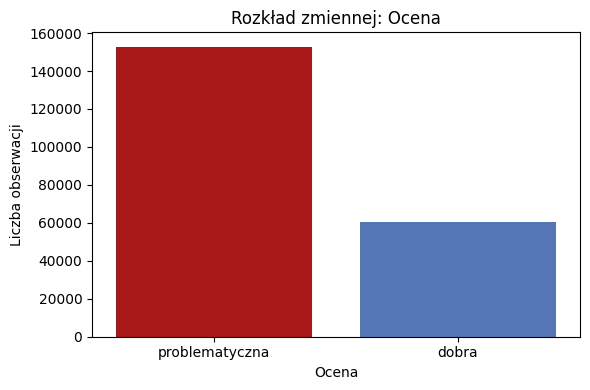

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot( data=dane,x='Ocena',palette={'dobra': '#4472C4','problematyczna': '#C00000'})

plt.title('Rozkład zmiennej: Ocena')
plt.xlabel('Ocena')
plt.ylabel('Liczba obserwacji')
plt.tight_layout()
plt.show()

### **Statystyki opisowe**

In [ ]:
statystyki = zmienne_ilosciowe.describe().T
statystyki = statystyki.rename(columns={
    'count': 'Liczba obserwacji',
    'mean': 'Średnia',
    'std': 'Odchylenie standardowe',
    'min': 'Minimum',
    '25%': 'Kwartyl 1',
    '50%': 'Mediana',
    '75%': 'Kwartyl 3',
    'max': 'Maksimum'})

statystyki = statystyki.round(2)
statystyki

,Liczba obserwacji,Średnia,Odchylenie standardowe,Minimum,Kwartyl 1,Mediana,Kwartyl 3,Maksimum
Initial Loan Amount,213206.0,54239.59,253040.64,11.3,517.50,1000.0,2045.19,5000000.0
Loan Rate Percent,213206.0,11.72,3.67,5.0,9.01,11.0,13.50,23.5
Term,213206.0,34.40,23.46,1.0,12.00,34.0,52.00,240.0
Mintos Risk Score,213206.0,7.39,1.16,4.6,6.60,7.3,8.60,9.4
Initial LTV,213206.0,3.96,18.81,0.0,0.00,0.0,0.00,129.0


In [ ]:
pd.set_option('display.max_columns', None)
statystyki_ocena = dane.groupby('Ocena')[zmienne_ilosciowe.columns].describe()

statystyki_ocena = statystyki_ocena.loc[:, (slice(None),['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'])]

statystyki_ocena.columns = statystyki_ocena.columns.set_levels([statystyki_ocena.columns.levels[0],
        ['Liczba obserwacji','Średnia','Odchylenie standardowe',
        'Minimum','Kwartyl 1','Mediana','Kwartyl 3','Maksimum']],level=[0, 1])

statystyki_ocena = statystyki_ocena.round(2)
statystyki_ocena

Initial Loan Amount                                          \
                 Liczba obserwacji  Średnia Odchylenie standardowe Minimum   
Ocena                                                                        
dobra                      60454.0   3022.4               49738.25    11.3   
problematyczna            152752.0  74509.6              294859.81    11.3   

                                                       Loan Rate Percent  \
               Kwartyl 1  Mediana Kwartyl 3   Maksimum Liczba obserwacji   
Ocena                                                                      
dobra             375.01   719.78   1378.88  4200000.0           60454.0   
problematyczna    622.88  1127.37   2528.09  5000000.0          152752.0   

                                                                         \
               Średnia Odchylenie standardowe Minimum Kwartyl 1 Mediana   
Ocena                                                                     
dobra            10.59                   2.40     5.0      9.00   10.35   
problematyczna   12.16                   3.98     5.0      9.05   11.10   

                                               Term          \
               Kwartyl 3 Maksimum Liczba obserwacji Średnia   
Ocena                                                         
dobra              12.00     23.5           60454.0   22.97   
problematyczna     14.49     23.5          152752.0   38.93   

                                                                           \
               Odchylenie standardowe Minimum Kwartyl 1 Mediana Kwartyl 3   
Ocena                                                                       
dobra                           21.07     1.0       9.0    12.0      36.0   
problematyczna                  22.81     1.0      23.0    37.0      56.0   

                        Mintos Risk Score                                 \
               Maksimum Liczba obserwacji Średnia Odchylenie standardowe   
Ocena                                                                      
dobra             240.0           60454.0    7.34                   1.30   
problematyczna    240.0          152752.0    7.41                   1.09   

                                                                  Initial LTV  \
               Minimum Kwartyl 1 Mediana Kwartyl 3 Maksimum Liczba obserwacji   
Ocena                                                                           
dobra              4.6       6.6     7.7       8.0      9.4           60454.0   
problematyczna     4.6       6.6     7.1       8.6      9.4          152752.0   

                                                                         \
               Średnia Odchylenie standardowe Minimum Kwartyl 1 Mediana   
Ocena                                                                     
dobra             2.66                  15.26     0.0       0.0     0.0   
problematyczna    4.47                  20.02     0.0       0.0     0.0   

                                   
               Kwartyl 3 Maksimum  
Ocena                              
dobra                0.0    129.0  
problematyczna       0.0    125.0